In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('pldb.csv')
df_reducido = df[['title', 'appeared', 'type', 'rank', 'lastActivity', 'bookCount', 'numberOfUsers', 'numberOfJobs', 'isOpenSource']]
df_reducido

/tmp/ipykernel_5386/1587099360.py:5: DtypeWarning: Columns (15,16,17,25,30,38,41,44,46,47,48,49,50,51,52,53,56,59,60,61,63,69,71,72,73,75,76,78,79,80,81,82,83,84,85,87,89,91,92,93,94,95,96,97,98,99,100,101,103,104,110,111,112,113,114,115,116,117,119,121,122,123,126,128,129,130,131,132,133,134,135,137,138,142,143,144,145,146,147,148,150,151,156,157,158,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,183,184,185,186,187,188,189,190,191,192,194,195,196,197,198,200,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,32

,title,appeared,type,rank,lastActivity,bookCount,numberOfUsers,numberOfJobs,isOpenSource
0,Java,1995,pl,0,2022,401,5550123,85206,NaN
1,JavaScript,1995,pl,1,2022,351,5962666,63993,NaN
2,C,1972,pl,2,2022,78,3793768,59919,NaN
3,Python,1991,pl,3,2022,342,2818037,46976,NaN
4,SQL,1974,queryLanguage,4,2022,182,7179119,219617,NaN
...,...,...,...,...,...,...,...,...,...
4813,Very Tiny Language,1976,pl,4813,1976,0,0,0,NaN
4814,wizml,1997,pl,4814,1997,0,0,0,NaN
4815,Wolontis-Bell Interpreter,1955,pl,4815,1955,0,0,0,NaN
4816,xl,1977,pl,4816,1977,0,0,0,NaN


In [4]:
df_reducido.isnull().sum()

,0
title,0
appeared,0
type,0
rank,0
lastActivity,0
bookCount,0
numberOfUsers,0
numberOfJobs,0
isOpenSource,4205


In [5]:
df_reducido.duplicated().sum()

np.int64(0)

# Perfilado: muestra estadísticas descriptivas

In [6]:
df_reducido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4818 entries, 0 to 4817
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          4818 non-null   object
 1   appeared       4818 non-null   int64 
 2   type           4818 non-null   object
 3   rank           4818 non-null   int64 
 4   lastActivity   4818 non-null   int64 
 5   bookCount      4818 non-null   int64 
 6   numberOfUsers  4818 non-null   int64 
 7   numberOfJobs   4818 non-null   int64 
 8   isOpenSource   613 non-null    object
dtypes: int64(6), object(3)
memory usage: 338.9+ KB


In [7]:
df_reducido.describe()

,appeared,rank,lastActivity,bookCount,numberOfUsers,numberOfJobs
count,4818.000000,4818.000000,4818.000000,4818.000000,4.818000e+03,4818.000000
mean,1989.014944,2408.500000,1998.455376,1.878165,1.505487e+04,399.992528
std,147.682103,1390.981129,131.016472,16.404652,2.231984e+05,11900.085667
min,-2700.000000,0.000000,-2700.000000,0.000000,0.000000e+00,0.000000
25%,1985.000000,1204.250000,1993.000000,0.000000,0.000000e+00,0.000000
50%,1998.000000,2408.500000,2007.000000,0.000000,2.900000e+01,0.000000
75%,2012.000000,3612.750000,2022.000000,0.000000,3.210000e+02,0.000000
max,2023.000000,4817.000000,2023.000000,401.000000,7.179119e+06,771996.000000


In [8]:
df_reducido['isOpenSource'] = df_reducido['isOpenSource'].fillna(False) #Cambio los nulos por falso, asumiendo que no si no dicen ser open source, entonces no lo son

/tmp/ipykernel_5386/705727194.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_reducido['isOpenSource'] = df_reducido['isOpenSource'].fillna(False) #Cambio los nulos por falso, asumiendo que no si no dicen ser open source, entonces no lo son
/tmp/ipykernel_5386/705727194.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reducido['isOpenSource'] = df_reducido['isOpenSource'].fillna(False) #Cambio los nulos por falso, asumiendo que no si no dicen ser open source, entonces no lo son


In [9]:
df_reducido['title'].unique()

array(['Java', 'JavaScript', 'C', ..., 'wizml',
       'Wolontis-Bell Interpreter', 'xl'], dtype=object)

In [11]:
df_reducido['title'] = df_reducido['title'].str.lower()
df_reducido = df_reducido.drop_duplicates()
df_reducido.duplicated().sum()

# Filtro los lenguajes de programacion, numero de usuarios mayor a 0 y año de aparicion mayor a 1900
df_pl = df_reducido[(df_reducido['type'] == 'pl') & (df_reducido['numberOfUsers'] > 0) & (df_reducido['appeared'] >= 1900)
].copy()

# Relacion de la cantidad de lenguajes de programacion y los años en los que aparecieron

En la distribucion de los lenguajes de programacion por años de aparicion podemos observar el auge de la programacion web en los 90s y la ciencia de datos en 2010s

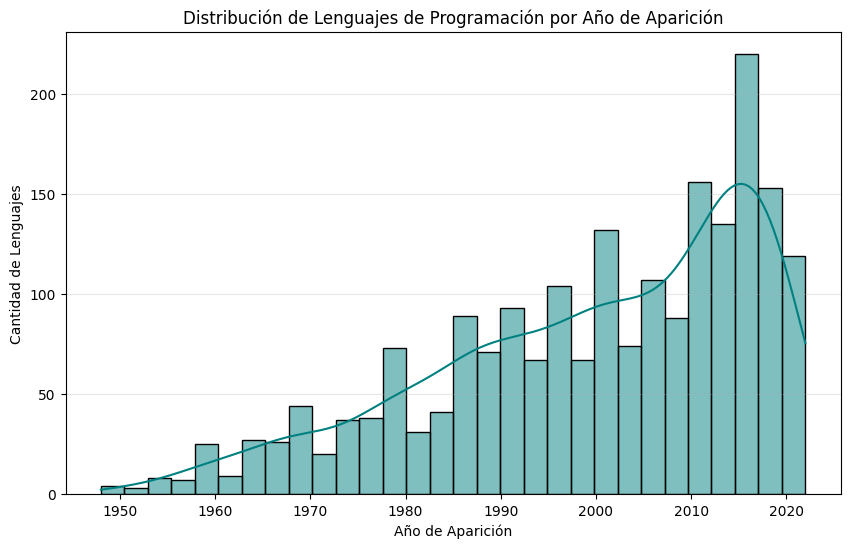

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_pl, x='appeared', bins=30, kde=True, color='teal')

plt.title('Distribución de Lenguajes de Programación por Año de Aparición')
plt.xlabel('Año de Aparición')
plt.ylabel('Cantidad de Lenguajes')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Relacion entre la cantidad de usuarios (popularidad del lenguaje) y la cantidad de trabajos que requieren ese lenguaje

Como se puede observar en el grafico, la relacion popularidad-empleo es notable, se puede apreciar que mientras mayor es la cantidad de usuarios que utilizan ese lenguaje, mayor tiende a ser la cantidad de puestos de trabajo relacionados con ese lenguaje.

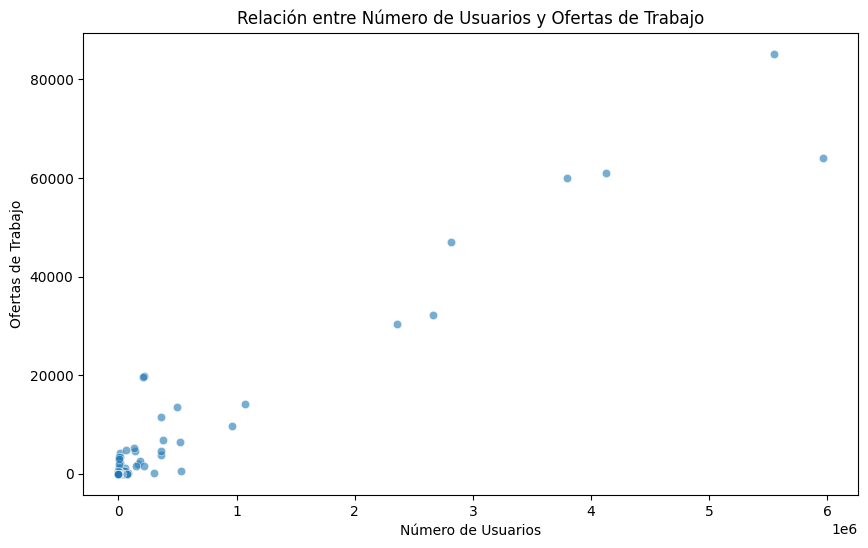

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pl, x='numberOfUsers', y='numberOfJobs', alpha=0.6)

plt.title('Relación entre Número de Usuarios y Ofertas de Trabajo')
plt.xlabel('Número de Usuarios')
plt.ylabel('Ofertas de Trabajo')
plt.show()

# Correlaciones de los datos obtenidos en el dataset

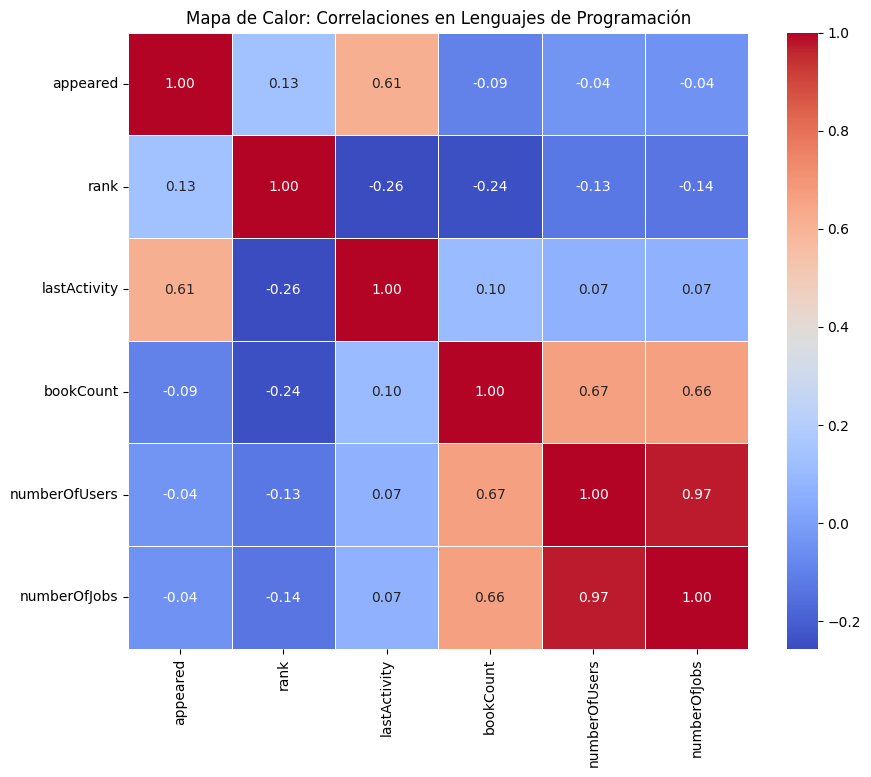

In [14]:
corr_matrix = df_pl[['appeared', 'rank', 'lastActivity', 'bookCount', 'numberOfUsers', 'numberOfJobs']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor: Correlaciones en Lenguajes de Programación')
plt.show()

# Relacion entre el ranking del lenguaje y la cantidad de usuarios

Podemos apreciar en el grafico que no en todos los casos se cumple que a mayor cantidad de usuarios mayor ranking, como en el paso de Perl, que tiene muchisimos menos usuarios que MATLAB e igual lo supera en ranking.
O casos como el de Python, que tiene una cantidad de usuarios similar a la de MATLAB pero este se encuentra 4 rankings sobre matlab

/tmp/ipykernel_5386/2487015300.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rank, x='numberOfUsers', y='title', palette='magma')


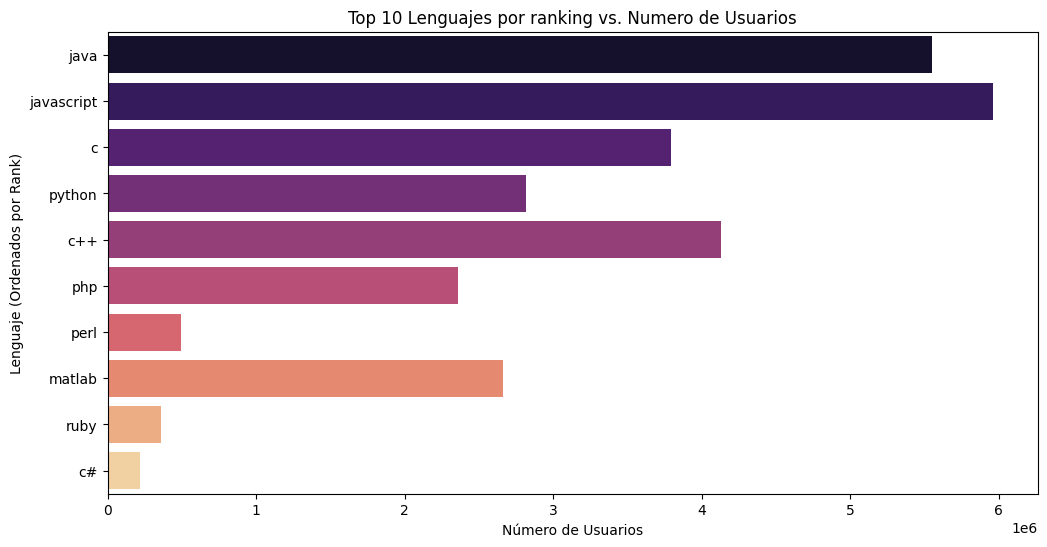

In [15]:
top_rank = df_pl.nsmallest(10, 'rank')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_rank, x='numberOfUsers', y='title', palette='magma')

plt.title('Top 10 Lenguajes por ranking vs. Numero de Usuarios')
plt.xlabel('Número de Usuarios')
plt.ylabel('Lenguaje (Ordenados por Rank)')
plt.show()

# Relacion entre la cantidad de libros escritos sobre ese lenguaje y el ranking en el que se encuentra

In [17]:
!pip install squarify

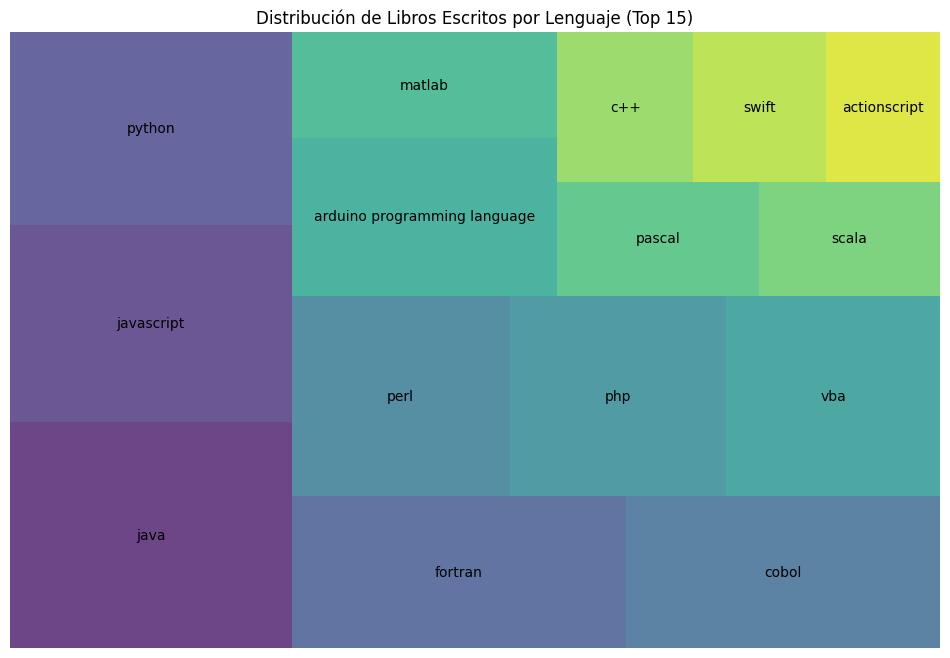

In [18]:
import squarify

top_books = df_pl.nlargest(15, 'bookCount')

plt.figure(figsize=(12, 8))
squarify.plot(sizes=top_books['bookCount'], label=top_books['title'], alpha=0.8, color=sns.color_palette("viridis", len(top_books)))
plt.title('Distribución de Libros Escritos por Lenguaje (Top 15)')
plt.axis('off')
plt.show()